# Import dependencies

In [64]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import json
import pingouin as pg
import scipy.stats as stats

# Create function to import and transform data

In [65]:
# import data from json file
def get_data(path):
    with open(path, 'r') as file:
        data = json.load(file)
    return data

In [68]:
# get gist data
def get_gist_data(test_dict):
    true_gist_x = test_dict[0]['trueCenter']['x']
    true_gist_y = test_dict[0]['trueCenter']['y']
    resp_gist_x = test_dict[0]['response']['x']
    resp_gist_y = test_dict[0]['response']['y']
    return true_gist_x, true_gist_y, resp_gist_x, resp_gist_y

In [69]:
# get item data
def get_ind_data(test_dict):
    num_dot  = len(test_dict)-1
    true_x = np.zeros(num_dot)
    true_y = np.zeros(num_dot)
    resp_x = np.zeros(num_dot)
    resp_y = np.zeros(num_dot)
    for i in range(num_dot):
        true_x[i] = test_dict[i+1]['trueLoc']['x']
        true_y[i] = test_dict[i+1]['trueLoc']['y']
        resp_x[i] = test_dict[i+1]['response']['x']
        resp_y[i] = test_dict[i+1]['response']['y']
    return true_x, true_y, resp_x, resp_y

In [ ]:
# get euclidean distance for memory error
def get_dist(true_x,true_y,resp_x,resp_y):
    #get x dist
    x_dist = np.power(true_x - resp_x, 2)
    #get y dist  
    y_dist = np.power(true_y - resp_y, 2)
    #sum 
    sum_dist = (np.sqrt(x_dist + y_dist))

    return sum_dist

# Loop over subjects

In [ ]:
#get datapath for both sessions 2
data_path_24hr1 = '/Users/chattarinpoungtubtim/Zeng2021/data/24h/phase1/'
data_path_24hr2 = '/Users/chattarinpoungtubtim/Zeng2021/data/24h/phase2/'
data_path_24hr = [data_path_24hr1,data_path_24hr2 ]
num_session = 2
#remove .DS
all_filename = sorted(os.listdir(data_path_24hr1))[1:]
num_sub = len(all_filename)
num_loc = 6
#create array to save data
all_error_ind = np.zeros((num_session,num_sub))
all_guess_ind = np.zeros((num_session,num_sub)) #if people just guess near screen center
all_error_gist = np.zeros((num_session,num_sub))
all_error_comb_gist = np.zeros((num_session,num_sub))
all_error_screen= np.zeros((num_session,num_sub)) #measure error relative to screen center
all_bias_ind = np.zeros((num_session,num_sub))
all_bias_screen = np.zeros((num_session,num_sub))
#create array to save individual trial data
trial_stim_x = np.zeros((num_session,num_sub,num_loc))
trial_stim_y = np.zeros((num_session,num_sub,num_loc))
trial_error_ind = np.zeros((num_session,num_sub,num_loc))
trial_bias_ind = np.zeros((num_session,num_sub,num_loc))
center_stim_x = np.zeros((num_session,num_sub))
center_stim_y = np.zeros((num_session,num_sub))


In [75]:
# select only test trials
start_idx = -9
end_idx = -2
screen_cent_x = 600
screen_cent_y = 320
# arrays to check gist response
good_gist_loc = np.zeros((num_session,num_sub))
# store elapse time
# loop over filenam
all_task_time = np.zeros((num_session,num_sub))
for sess in range(num_session):
    data_path = data_path_24hr[sess]
    for sub in range(num_sub):
        filename = all_filename[sub]
        file_path = data_path + filename
        data = get_data(file_path)
        test_dict = data['events'][start_idx:end_idx]

        # get stim location and response
        true_gist_x, true_gist_y, resp_gist_x, resp_gist_y = get_gist_data(test_dict)
        true_x, true_y, resp_x, resp_y = get_ind_data(test_dict)

        #get gist from ind. response
        comb_gist_x = np.average(resp_x)
        comb_gist_y = np.average(resp_y)

        guess_x = np.repeat(screen_cent_x,len(true_x))
        guess_y = np.repeat(screen_cent_y,len(true_y))
        
        # collect stim location
        trial_stim_x[sess,sub,:] = true_x
        trial_stim_y[sess,sub,:] = true_y
        center_stim_x[sess,sub] = true_gist_x
        center_stim_y[sess,sub] = true_gist_y

        # get error
        error_ind = get_dist(true_x,true_y,resp_x,resp_y)
        avg_error_ind = np.average(error_ind)
        avg_error_gist = get_dist(true_gist_x,true_gist_y,resp_gist_x,resp_gist_y)
        error_comb_gist = get_dist(true_gist_x,true_gist_y,comb_gist_x,comb_gist_y)
        avg_error_screen = get_dist(screen_cent_x ,screen_cent_y,resp_gist_x,resp_gist_y)
        guess_ind = get_dist(guess_x,guess_y,resp_x,resp_y)
        avg_guess_ind = np.average(guess_ind)

        # get bias
        bias = (get_dist(resp_gist_x,resp_gist_y,true_x,true_y) - get_dist(resp_gist_x,resp_gist_y,resp_x,resp_y))/error_ind
        avg_bias = np.average(bias)
        bias_screen = (get_dist(true_gist_x,true_gist_y,resp_gist_x, resp_gist_y) - get_dist(screen_cent_x ,screen_cent_y,resp_gist_x,resp_gist_y))/get_dist(true_gist_x,true_gist_y,resp_gist_x, resp_gist_y) 
        avg_bias_screen = np.average(bias_screen)

        # collect data
        all_error_ind[sess,sub] = avg_error_ind
        all_guess_ind[sess,sub] = avg_guess_ind
        all_error_gist[sess,sub] = avg_error_gist
        all_error_comb_gist[sess,sub] = error_comb_gist 
        all_error_screen[sess,sub] = avg_error_screen
        all_bias_ind[sess,sub] = avg_bias
        all_bias_screen[sess,sub] = avg_bias_screen

        trial_error_ind[sess,sub,:] = error_ind
        trial_bias_ind[sess,sub,:] = bias

        # check whether gist response is within landmarks
        max_x = np.max(true_x)
        min_x = np.min(true_x)
        max_y = np.max(true_y)
        min_y = np.min(true_y)
        good_gist_x = resp_gist_x >= min_x and resp_gist_x <= max_x
        good_gist_y = resp_gist_y >= min_y and resp_gist_y <= max_y
        good_gist_loc[sess,sub] = int(good_gist_x and good_gist_y)

        #get time
        total_time = ((data['events'][-2]['t'] - data['events'][0]['t']) / 60000)  # turn millisec into minutes
        all_task_time[sess,sub] = total_time

# Bias simulation for each subjects

In [76]:
num_sim = 10000
num_angle = 3600
random_ang = np.arange(0,2 * np.pi,2 * np.pi/num_angle)
sim_bias = np.zeros((num_session,num_sub))
for sess in range(num_session):
    for sub in range(num_sub):
        this_center_x = center_stim_x[sess,sub]
        this_center_y = center_stim_y[sess,sub]
        min_x = 0
        max_x = 1000
        min_y = 0
        max_y = 640
        avg_bias = 0
        for loc in range(num_loc):
            #get stim location
            this_stim_x = trial_stim_x[sess,sub,loc]
            this_stim_y = trial_stim_y[sess,sub,loc]
            #get error for this trial
            this_error = trial_error_ind[sess,sub,loc]
            #simulate angle for error
            sim_error_angle = np.random.choice(random_ang,size=num_sim)
            #get error for both axis
            sim_error_x = this_error * np.cos(sim_error_angle)
            sim_error_y= this_error * np.sin(sim_error_angle)
            #get simulated responses
            sim_response_x = this_stim_x + sim_error_x
            sim_response_y = this_stim_y + sim_error_y
            #check whether sim. responses are in bound
            in_bound_x = np.logical_or(sim_response_x >= min_x,sim_response_x <= max_x)
            in_bound_y = np.logical_or(sim_response_y >= min_y,sim_response_y <= max_y)
            in_bound_all = np.logical_and(in_bound_x, in_bound_y)
            #get gist dist for all sim. responses
            gist_resp_dist = np.sqrt(((sim_response_x - this_center_x) ** 2) + ((sim_response_y - this_center_y) ** 2))
            #average over only in bound responses
            gist_resp_dist_in = gist_resp_dist[in_bound_all]
            avg_gist_resp_dist = np.average(gist_resp_dist_in)
            #get target-gist dist
            gist_tar_dist = np.sqrt(((this_stim_x - this_center_x) ** 2) + ((this_stim_y - this_center_y) ** 2))
            #get bias
            this_bias = (gist_tar_dist - avg_gist_resp_dist) / gist_tar_dist
            avg_bias += this_bias
        avg_bias /= num_loc
        sim_bias[sess,sub] = avg_bias

# Create dataframe for results

In [112]:
all_sub_data_dict = {'ID_sub': np.arange(1, num_sub + 1),'gist_error_session_1' : all_error_gist[0,:], 'gist_error_session_2' : all_error_gist[1,:], 'avg_ind_error_session_1' : all_error_ind[0,:], 'avg_ind_error_session_2' : all_error_ind[1,:], 'obs_bias_session_1' : all_bias_ind[0,:], 'obs_bias_session_2' : all_bias_ind[1,:], 'sim_bias_session_1' : sim_bias[0,:], 'sim_bias_session_2' : sim_bias[1,:], 'good_gist_loc_session_1' : good_gist_loc[0,:], 'good_gist_loc_session_2' : good_gist_loc[1,:] }
all_sub_df = pd.DataFrame(all_sub_data_dict)

In [110]:
all_sub_df.head()

,ID_sub,gist_error_session_1,gist_error_session_2,avg_ind_error_session_1,avg_ind_error_session_2,obs_bias_session_1,obs_bias_session_2,sim_bias_session_1,sim_bias_session_2,good_gist_loc_session_1,good_gist_loc_session_2
0,1,142.670624,185.661572,87.620940,234.093908,-0.138723,0.226701,-0.049529,-0.403400,1.0,1.0
1,2,120.789364,186.078667,54.277578,208.320297,-0.544115,-0.023487,-0.018634,-0.344669,1.0,1.0
2,3,189.677411,140.563937,31.115206,205.604833,0.080477,-0.129881,-0.005666,-0.316992,1.0,1.0
3,4,29.924828,68.145674,12.290041,94.245838,-0.403716,-0.167618,-0.000886,-0.064229,1.0,1.0
4,5,280.742334,267.472303,60.381061,82.987916,0.208206,0.263404,-0.017302,-0.043626,0.0,0.0


In [132]:
all_sub_df.to_csv('/Users/chattarinpoungtubtim/Zeng2021/analysis/all_sub_data.csv')

# Exclusion of poor data

In [114]:
# Get data as numpy array
## Item memory errors for session 1 and 2
all_error_ind_s1 = all_sub_df['avg_ind_error_session_1'].to_numpy()
all_error_ind_s2 = all_sub_df['avg_ind_error_session_2'].to_numpy()
## Gist memory errors for session 1 and 2
all_error_gist_s1 = all_sub_df['gist_error_session_1'].to_numpy()
all_error_gist_s2 = all_sub_df['gist_error_session_2'].to_numpy()
## Gist response conditions for session 1 and 2 (is the response lie within the boundary)
all_good_gist_s1 = all_sub_df['good_gist_loc_session_1'].to_numpy()
all_good_gist_s2 = all_sub_df['good_gist_loc_session_2'].to_numpy()

In [ ]:
# Exclude data
## exclusion criteria 1 : bad item memory performance compared to group
### session 1 check
all_avg_error_ind_s1 = np.median(all_error_ind_s1)
all_std_error_ind_s1 = np.std(all_error_ind_s1)
low_error_ind_s1 = all_avg_error_ind_s1+ (3 * all_std_error_ind_s1)
### session 2 check
all_avg_error_ind_s2 = np.median(all_error_ind_s2)
all_std_error_ind_s2 = np.std(all_error_ind_s2)
low_error_ind_s2 = all_avg_error_ind_s2 + (3 * all_std_error_ind_s2)
## exclusion criteria 2 : bad item memory performance compared to group
### session 1 check
all_avg_error_gist_s1 = np.median(all_error_gist_s1)
all_std_error_gist_s1 = np.std(all_error_gist_s1)
low_error_gist_s1 = all_avg_error_gist_s1 + (3 * all_std_error_gist_s1)
### session 2 check
all_avg_error_gist_s2 = np.median(all_error_gist_s2)
all_std_error_gist_s2 = np.std(all_error_gist_s2)
low_error_gist_s2 = all_avg_error_gist_s2 + (3 * all_std_error_gist_s2)
## combine 1 and 2
good_avg_perf_s1 = np.logical_and(all_error_ind_s1 <= low_error_ind_s1, all_error_gist_s1 <= low_error_gist_s1)
good_avg_perf_s2 = np.logical_and(all_error_ind_s2  <= low_error_ind_s2, all_error_gist_s2 <= low_error_gist_s2)
good_avg_perf_all = np.logical_and(good_avg_perf_s1,good_avg_perf_s2)
## combine with good gist response
good_gist_both = np.logical_and(all_good_gist_s1,all_good_gist_s2)
good_sub_all = np.logical_and(good_avg_perf_all,good_gist_both)
## get clean subjects
ID_good_sub = all_sub_df['ID_sub'].to_numpy()[good_sub_all]
## get clean dataframe
clean_sub_df = all_sub_df[all_sub_df['ID_sub'].isin(ID_good_sub)]

# Stat test

In [124]:
# prepare for stat tests for memory error
error_df = clean_sub_df[['ID_sub','avg_ind_error_session_1','avg_ind_error_session_2','gist_error_session_1','gist_error_session_2']]
# copy dataframe
error_cop = error_df.copy()
## melt dataframe before doing stat tests
error_melt = pd.melt(error_cop,id_vars='ID_sub',value_vars=['avg_ind_error_session_1','avg_ind_error_session_2','gist_error_session_1','gist_error_session_2'])
## create 2 factor conditons (sessions x memory types)
session_cond = []
mem_cond = []
### mem cond - 0 : ind, 1 : gist
### session cond - 1 : 0, 2 : 1
for i in range(len(error_melt['ID_sub'])):
    if error_melt['variable'][i] == 'avg_ind_error_session_1':
        session_cond.append(0)
        mem_cond.append(0)
    elif error_melt['variable'][i] == 'avg_ind_error_session_2':
        session_cond.append(1)
        mem_cond.append(0)
    elif error_melt['variable'][i] == 'avg_gist_error_session_1':
        session_cond.append(0)
        mem_cond.append(1) 
    else: 
        session_cond.append(1)
        mem_cond.append(1)
error_melt['session_cond'] = session_cond
error_melt['mem_cond'] = mem_cond

In [126]:
# 2 x 2 anova for memory error
aov_error = pg.rm_anova(data=error_melt, dv='value',subject ='ID_sub', within=['session_cond','mem_cond'], correction=False, effsize="np2")
## print resulr for ANOVA
pg.print_table(aov_error)


ANOVA SUMMARY

Source                            SS    ddof1    ddof2           MS        F    p-unc    p-GG-corr    np2    eps
-----------------------  -----------  -------  -------  -----------  -------  -------  -----------  -----  -----
session_cond              365278.566        1       34   365278.566  146.223    0.000        0.000  0.811  1.000
mem_cond                   48452.364        1       34    48452.364   16.830    0.000        0.000  0.331  1.000
session_cond * mem_cond  -189175.084        1       34  -189175.084  419.943    0.000        0.000  0.925  1.000



/opt/homebrew/anaconda3/lib/python3.13/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [128]:
# post hoc paired t-test for memory error
## get difference of memory error between session 2 and 1 for both item and gist memories
diff_err_ind = error_df['avg_ind_error_session_2'].to_numpy() - error_df['avg_ind_error_session_1'].to_numpy()
diff_err_gist = error_df['gist_error_session_2'].to_numpy() - error_df['gist_error_session_1'].to_numpy()
t_stats, p_val = stats.ttest_rel(diff_err_ind,diff_err_gist)
## get degree of freedom
t_df = np.sum(good_sub_all)-1
## effect size : Cohen's D
cohen_d_err = np.mean(diff_err_ind-diff_err_gist)/np.std(diff_err_ind-diff_err_gist)
## print result
print(f'post-hoc t-test : t({t_df}) = {t_stats}, p = {p_val}, Cohens D = {cohen_d_err}')

post-hoc t-test : t(34) = 4.681652095722693, p = 4.426437775837793e-05, Cohens D = 0.8028967105459032


In [130]:
# prepare for stat tests for memory bias
bias_df = clean_sub_df[['ID_sub','obs_bias_session_1','obs_bias_session_2','sim_bias_session_1','sim_bias_session_2']]
# copy dataframe
bias_cop = bias_df.copy()
## melt dataframe before doing stat tests
bias_melt = pd.melt(bias_cop,id_vars='ID_sub',value_vars=['obs_bias_session_1','obs_bias_session_2','sim_bias_session_1','sim_bias_session_2'])
## create 2 factor conditons (sessions x memory types)
session_cond = []
bias_cond = []
### bias cond - 0 : observed, 1 : simulated
### session cond - 1 : 0, 2 : 1
for i in range(len(bias_melt['ID_sub'])):
    if bias_melt['variable'][i] == 'obs_bias_session_1':
        session_cond.append(0)
        bias_cond.append(0)
    elif bias_melt['variable'][i] == 'obs_bias_session_2':
        session_cond.append(1)
        bias_cond.append(0)
    elif bias_melt['variable'][i] == 'sim_bias_session_1':
        session_cond.append(0)
        bias_cond.append(1) 
    else: 
        session_cond.append(1)
        bias_cond.append(1)
bias_melt['session_cond'] = session_cond
bias_melt['bias_cond'] = bias_cond

# 2 x 2 anova for memory bias
aov_bias = pg.rm_anova(data=bias_melt, dv='value',subject ='ID_sub', within=['session_cond','bias_cond'], correction=False, effsize="np2")
## print resulr for ANOVA
print(' 2 x 2 ANOVA for memory biases (sessions vs memory types)')
pg.print_table(aov_bias)

 2 x 2 ANOVA for memory biases (sessions vs memory types)

ANOVA SUMMARY

Source                       SS    ddof1    ddof2     MS       F    p-unc    p-GG-corr    np2    eps
------------------------  -----  -------  -------  -----  ------  -------  -----------  -----  -----
session_cond              0.127        1       34  0.127   2.968    0.094        0.094  0.080  1.000
bias_cond                 0.555        1       34  0.555   7.795    0.009        0.009  0.187  1.000
session_cond * bias_cond  0.791        1       34  0.791  15.384    0.000        0.000  0.312  1.000



/opt/homebrew/anaconda3/lib/python3.13/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/opt/homebrew/anaconda3/lib/python3.13/site-packages/pingouin/distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


In [131]:
# post hoc paired t-test for memory biases
## compare memory bias between session 1 and 2 
t_stats_ses, p_val_ses = stats.ttest_rel(bias_df['obs_bias_session_2'].to_numpy(),bias_df['obs_bias_session_1'].to_numpy())
## get degree of freedom
t_df_ses = np.sum(good_sub_all)-1
## effect size : Cohen's D
diff_bias_ses = bias_df['obs_bias_session_2'].to_numpy()-bias_df['obs_bias_session_1'].to_numpy()
cohen_d_bias_ses = np.mean(diff_bias_ses)/np.std(diff_bias_ses)
## print result
print(f'post-hoc t-test for memory biases difference over time (phase 1 vs phase 2) : t({t_df_ses}) = {t_stats_ses}, p = {p_val_ses}, Cohens D = {cohen_d_bias_ses}')
## compare memory bias between observed and simulated at session 1 
t_stats_sim1, p_val_sim1 = stats.ttest_rel(bias_df['obs_bias_session_1'].to_numpy(),bias_df['sim_bias_session_1'].to_numpy())
## get degree of freedom
t_df_sim1 = np.sum(good_sub_all)-1
## effect size : Cohen's D
diff_bias_sim1 = bias_df['obs_bias_session_1'].to_numpy()-bias_df['sim_bias_session_1'].to_numpy()
cohen_d_bias_sim1 = np.mean(diff_bias_sim1)/np.std(diff_bias_sim1)
## print result
print(f'post-hoc t-test for memory biases difference at session 1 (observed vs simulated) : t({t_df_sim1}) = {t_stats_sim1}, p = {p_val_sim1}, Cohens D = {cohen_d_bias_sim1}')
## compare memory bias between observed and simulated at session 2 
t_stats_sim2, p_val_sim2 = stats.ttest_rel(bias_df['obs_bias_session_2'].to_numpy(),bias_df['sim_bias_session_2'].to_numpy())
## get degree of freedom
t_df_sim2 = np.sum(good_sub_all)-1
## effect size : Cohen's D
diff_bias_sim2 = bias_df['obs_bias_session_2'].to_numpy()-bias_df['sim_bias_session_2'].to_numpy()
cohen_d_bias_sim2 = np.mean(diff_bias_sim2)/np.std(diff_bias_sim2)
## print result
print(f'post-hoc t-test for memory biases difference at session 2 (observed vs simulated) : t({t_df_sim2}) = {t_stats_sim2}, p = {p_val_sim2}, Cohens D = {cohen_d_bias_sim2}')

post-hoc t-test for memory biases difference over time (phase 1 vs phase 2) : t(34) = 1.4490545469956508, p = 0.15648355813408496, Cohens D = 0.2485108046040732
post-hoc t-test for memory biases difference at session 1 (observed vs simulated) : t(34) = -0.40476235165735813, p = 0.6881875358785571, Cohens D = -0.06941617062819153
post-hoc t-test for memory biases difference at session 2 (observed vs simulated) : t(34) = 4.769479707755545, p = 3.411669224497952e-05, Cohens D = 0.8179590217459823


# Plot results for memory error

In [140]:
def plot_bar_and_scatter(data1,data2,title,labels,ylabel,color=(0, 0.4, 0, 1),bar_width=0.4,capsize=12,ylim=350):
    x = np.arange(0,len(labels))
    #get mean across conditions (within subjects)
    mean_data = (data1 + data2) / 2
    #demean both data
    demean_data1 = data1 - mean_data
    demean_data2 = data2 - mean_data
    #get mean
    mean_data = [np.mean(data1), np.mean(data2)]
    #get std error
    std_error_data = [np.std(demean_data1), np.std(demean_data2)]
    #set up plot
    fig, ax = plt.subplots()
    colors = [color, color] 
    #plot bar
    ax.bar(x,
       height=mean_data,
       yerr=std_error_data,    # error bars
       capsize=12, # error bar cap width in points
       width=bar_width,    # bar width
       tick_label=labels,
       color=(0,0,0,0),  # face color transparent
       edgecolor=colors
       )

    #plot scatter
    ax.scatter(x[0] + np.random.random(data1.size) * bar_width - bar_width / 2, data1, color=colors[0],alpha=0.5)   
    ax.scatter(x[1] + np.random.random(data2.size) * bar_width - bar_width / 2, data2, color=colors[1],alpha=0.5)  

    plt.title(title)
    plt.ylabel(ylabel)
    plt.ylim(0,ylim)
    plt.show()
    


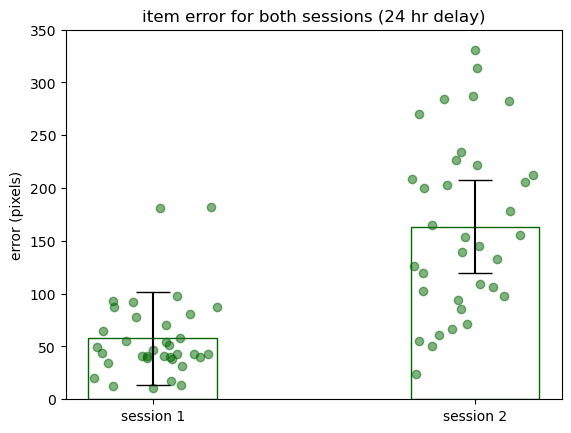

In [141]:
#plot data for item errors
data1 = all_error_ind_s1[good_sub_all]
data2 = all_error_ind_s2[good_sub_all]
title = 'item error for both sessions (24 hr delay)'
labels = ['session 1', 'session 2']
ylabel = 'error (pixels)'
plot_bar_and_scatter(data1,data2,title,labels,ylabel)

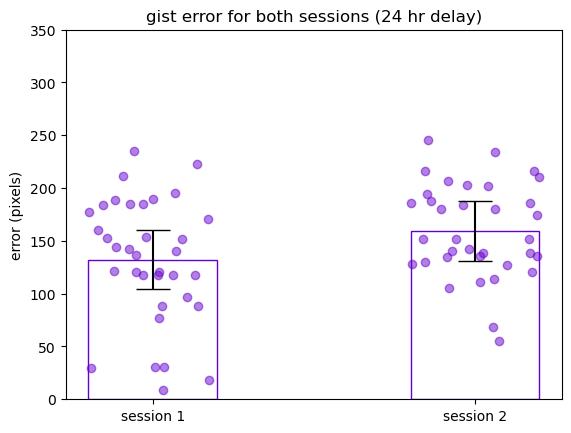

In [ ]:
#plot data for gist errors
data1 = all_error_gist_s1[good_sub_all]
data2 = all_error_gist_s2[good_sub_all]
title = 'gist error for both sessions (24 hr delay)'
labels = ['session 1', 'session 2']
ylabel = 'error (pixels)'
color = (0.4, 0, 0.8, 1)
plot_bar_and_scatter(data1,data2,title,labels,ylabel,color)

In [146]:
#get bias data and exclude poor performers
all_obs_bias_s1 = all_sub_df['obs_bias_session_1'].to_numpy()[good_sub_all]
all_obs_bias_s2 = all_sub_df['obs_bias_session_2'].to_numpy()[good_sub_all]
all_sim_bias_s1 = all_sub_df['sim_bias_session_1'].to_numpy()[good_sub_all]
all_sim_bias_s2 = all_sub_df['sim_bias_session_2'].to_numpy()[good_sub_all]

In [149]:
# get mean and std error for observed bias (both sessions)
avg_obs_bias_both = (all_obs_bias_s1  + all_obs_bias_s2 )/2
demean_obs_bias_s1 = all_obs_bias_s1  - avg_obs_bias_both
demean_obs_bias_s2 = all_obs_bias_s2   - avg_obs_bias_both
mean_obs_bias_both_sess = [np.mean(all_obs_bias_s1), np.mean(all_obs_bias_s2)]
std_obs_bias_both_sess = [np.std(demean_obs_bias_s1), np.std(demean_obs_bias_s2)]

# get mean and std error for simulated bias (both sessions)
avg_sim_bias_both = (all_sim_bias_s1  + all_sim_bias_s2 )/2
demean_sim_bias_s1 = all_sim_bias_s1  - avg_sim_bias_both
demean_sim_bias_s2 = all_sim_bias_s2   - avg_sim_bias_both
mean_sim_bias_both_sess = [np.mean(all_sim_bias_s1), np.mean(all_sim_bias_s2)]
std_sim_bias_both_sess = [np.std(demean_sim_bias_s1), np.std(demean_sim_bias_s2)]



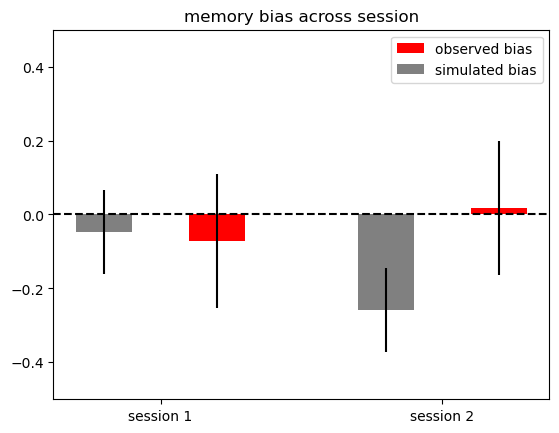

In [ ]:
# plot data for memory bias
bar_w = 0.2
x_int = np.arange(len(labels))
plt.bar(x_int+bar_w, mean_obs_bias_both_sess, yerr=std_obs_bias_both_sess, width=bar_w, label='observed bias', color='red')
plt.bar(x_int-bar_w, mean_sim_bias_both_sess, yerr=std_sim_bias_both_sess,  width=bar_w, label='simulated bias', color='gray')
plt.xticks(x_int,labels)
plt.axhline(0,linestyle='--',color='black')
plt.ylim(-0.5,0.5)
plt.title('memory bias across session')
plt.legend()
plt.show()
